# **Time Series Handson**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data= pd.read_csv('/content/AirPassengers.csv')

In [ ]:
data

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
data["Month"]= pd.to_datetime(data["Month"])  # Converting Month to int format

In [ ]:
data

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
data.isnull().sum()  # Checking for Null values

,0
Month,0
#Passengers,0


In [ ]:
data.duplicated().sum()  # Checking for duplicate records

0

In [ ]:
data

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [ ]:
data.set_index("Month",inplace=True)  # Making Month columns as index

In [ ]:
data

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


<Axes: xlabel='Month'>

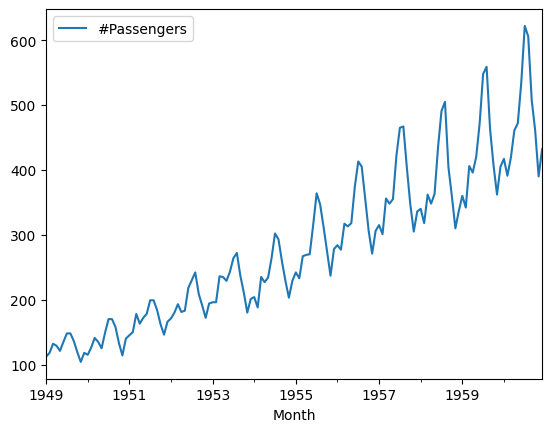

In [ ]:
data.plot()  # Drawing a plot to check seasionality and trend

**This graph shows that our data has both seasionality and trend**

Figure(640x480)


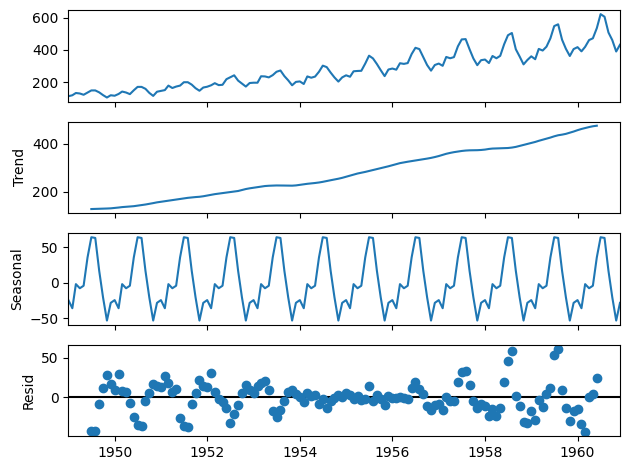

In [ ]:
'''
seasonal_decompose(data) takes your time series data as input and decomposes it into three main components:

Trend: The overall direction or pattern in the data over a long period.
Seasonality: The repeating short-term cycle in the data (e.g., monthly or quarterly patterns).
Residual (Noise): The random variation or noise left after removing the trend and seasonality.
'''
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed= seasonal_decompose(data)
print(decomposed.plot())

#shapiro wilk test is used to check whethervthe data is normally distributed or not

**Checking that the data is stationary or not**

In [ ]:
from statsmodels.tsa.stattools import adfuller   #Augumented -Dickey Fuller Test
test_result= adfuller(data)

In [ ]:
pval=test_result[1]
pval

0.991880243437641

In [ ]:
# null hypothesis: data is not stationary
# alternate hypothesis: data is stationary

# If p value less < than 0.05      - We accepted the alternate hypothesis ( Data is stationary )
# If p values greater > than 0.05  - We fail to reject the null hypothesis ( Data is not stationary )

In [ ]:
if pval<0.05:
  print("Data is stationary")
else:
  print("Data is not stationary")

Data is not stationary


**Stationarity: A stationary time series has constant mean and variance over time, which is crucial for many time series forecasting models.**

**As our data is not stationary we need to convert it to stationary form before model building**

To convert a non-stationary time series into a stationary one, we often use techniques that stabilize the mean and variance over time.

1) Remove seasionality

2) Remove trend

**Logarithmic Transformation:** Applying a logarithm to the data is a common technique to stabilize the variance (reduce heteroscedasticity) and make the time series more stationary. This transformation compresses the scale of the data, especially for large values, and is particularly useful when dealing with exponential growth trends in time series data.

<Axes: xlabel='Month'>

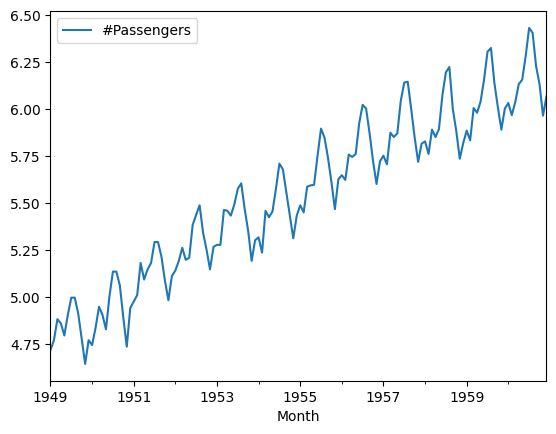

In [ ]:
#logrithmic comutation to make the time series stationary
first_log = np.log(data)
first_log = first_log.dropna()
first_log.plot()

In [ ]:
first_log

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


**Rolling Mean (mean_log)**: This computes the moving average of the time series over a specified window (in this case, 12 time periods). It helps smooth out short-term fluctuations and highlights longer-term trends.

**Rolling Standard Deviation (std_log)**: Similarly, this computes the moving standard deviation over the same window, showing how much variation exists around the rolling mean.

Text(0.5, 1.0, 'Rolling Mean & Standard Deviation (Logarithmic Scale)')

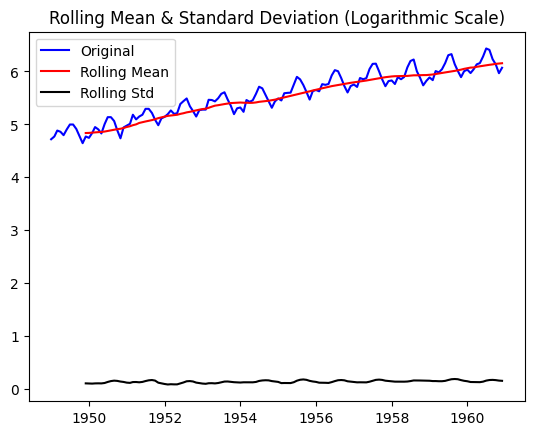

In [ ]:
mean_log = first_log.rolling(window=12).mean()
std_log = first_log.rolling(window=12).std()

plt.plot(first_log, color='blue', label='Original')
plt.plot(mean_log, color='red', label='Rolling Mean')
plt.plot(std_log, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation (Logarithmic Scale)')

In [ ]:
mean_log.head(20)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


**Why NaN Values Appear:**

**Rolling Mean/Standard Deviation:** When you calculate a rolling mean or standard deviation over a window (e.g., 12 months), the first few values in the time series cannot be computed because there aren't enough preceding data points to fill the window. For instance, if you calculate a 12-month rolling mean, the first 11 months will have NaN values because there's insufficient data to compute the average.

**Example:** For the date 1949-01-01, the rolling window (12 months) does not have enough previous data points to calculate the rolling mean or standard deviation, hence it results in NaN.

In [ ]:
std_log.head(20)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


By subtracting the rolling mean from the log-transformed data, you're removing the trend component from the data. This is a common technique in time series analysis to achieve stationarity.

In [ ]:
new_data = first_log - mean_log
new_data = new_data.dropna()
new_data.head(20)

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
1950-05-01,-0.027529
1950-06-01,0.139881
1950-07-01,0.260184
1950-08-01,0.248635


Text(0.5, 1.0, 'Rolling Mean & Standard Deviation (Logarithmic Scale)')

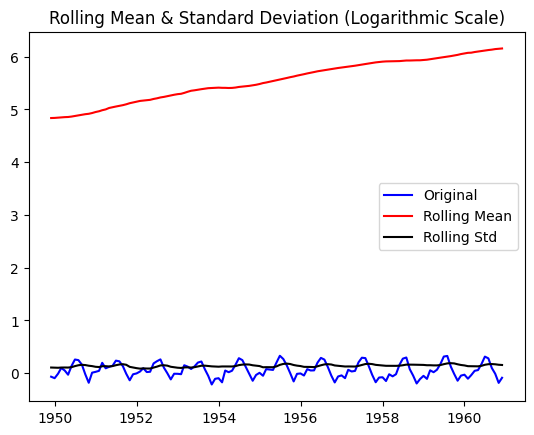

In [ ]:
# mean_log = new_data.rolling(window=12).mean()
# std_log = new_data.rolling(window=12).std()

plt.plot(new_data, color='blue', label='Original')
plt.plot(mean_log, color='red', label='Rolling Mean')
plt.plot(std_log, color='black', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation (Logarithmic Scale)')

<Axes: xlabel='Month'>

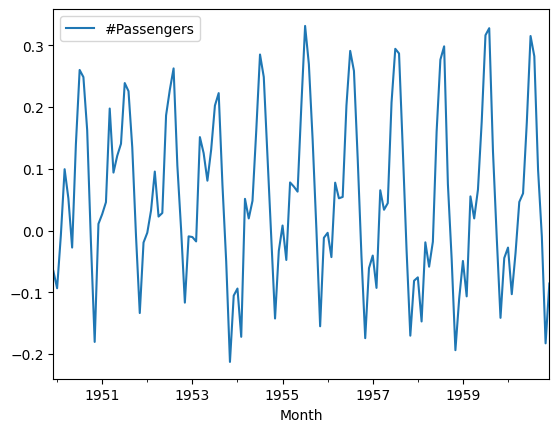

In [ ]:
new_data.plot()  # Drawing a plot to check seasionality and trend

**Again checking whether the data is staionary or not**

In [ ]:
result=adfuller(new_data)

In [ ]:
p_value= result[1]
p_value

0.022234630001242206

In [ ]:
if p_value<0.05:
  print("Data is stationary,Null hypothesis Rejected")
else:
  print("Data is not stationary")

Data is stationary,Null hypothesis Rejected


# Model building

In [ ]:
# splitting data into train and test
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [ ]:
train= new_data.iloc[:120]["#Passengers"]
test= new_data.iloc[120:]["#Passengers"]

In [ ]:
train

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1959-07-01,0.316430
1959-08-01,0.327838
1959-09-01,0.128057


In [ ]:
train.shape

(120,)

In [ ]:
test

,#Passengers
Month,
1959-12-01,-0.044481
1960-01-01,-0.027530
1960-02-01,-0.103067
1960-03-01,-0.036530
1960-04-01,0.046332
1960-05-01,0.060186
1960-06-01,0.175033
1960-07-01,0.315151
1960-08-01,0.282363


In [ ]:
test.shape

(13,)

In [ ]:
# Implementation of ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# # ARIMA -AutoRegressive Integrated Moving Average
# ARIMA - (p,d,q)

# p - order of lag   ,  p= ?
# d - degree of differencing  d=1
# q - order of moving average q= ?

'''
p: How many past values you want to use for prediction.
d: How many times you need to subtract past values to make the data steady.
q: How many past errors you want to use to improve your predictions.
'''

'\np: How many past values you want to use for prediction.\nd: How many times you need to subtract past values to make the data steady.\nq: How many past errors you want to use to improve your predictions.\n'

In [ ]:
A_model=ARIMA(train,order=(6,1,6))  #randomly picking up the values of p and q , now i'm replacing with optimal value 6,1,6

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
A_model=A_model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Predict for last 12 month for year 1960
new_data["ARIMA_prediction"]=A_model.predict(start=len(train),end=len(train)+len(test)-1)
# start = 120
# end = 132 (  120+13-1 )

In [ ]:
new_data.tail(12)

,#Passengers,ARIMA_prediction
Month,,
1960-01-01,-0.027530,-0.078208
1960-02-01,-0.103067,-0.102482
1960-03-01,-0.036530,-0.036334
1960-04-01,0.046332,0.081086
1960-05-01,0.060186,0.155306
1960-06-01,0.175033,0.192317
1960-07-01,0.315151,0.205018
1960-08-01,0.282363,0.177301
1960-09-01,0.098235,0.107395


<Axes: xlabel='Month'>

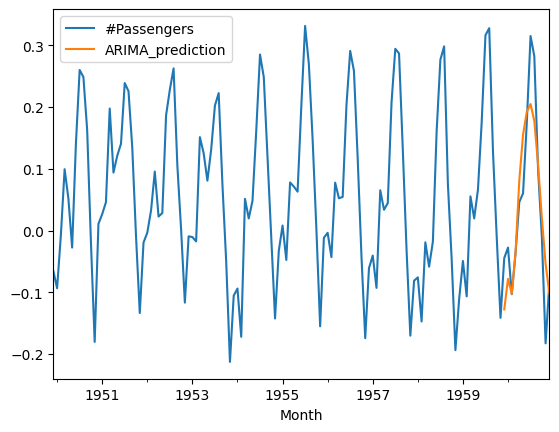

In [ ]:
new_data[["#Passengers","ARIMA_prediction"]].plot()

In [ ]:
from sklearn.metrics import *

In [ ]:
#finding optimal values of p,d,q with itertools
import itertools
p=range(0,7)
d=range(1,2)
q=range(0,7)
pdq=list(itertools.product(p,d,q))
rmse = []
order1 =[]
for i in pdq:
    model = ARIMA(train, order = i)
    model_fit = model.fit()
    pred = model_fit.predict(start = len(train), end= len(train)+len(test)-1)
    error = np.sqrt(mean_squared_error(test,pred))
    order1.append(i)
    rmse.append(error)

results = pd.DataFrame(index = order1, data = rmse, columns=['RMSE'])

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
results.sort_values(by='RMSE',ascending=True)

,RMSE
"(6, 1, 6)",0.068580
"(4, 1, 6)",0.072426
"(5, 1, 6)",0.074114
"(6, 1, 1)",0.097964
"(6, 1, 5)",0.111533
"(4, 1, 3)",0.114331
"(3, 1, 3)",0.115135
"(6, 1, 2)",0.124454
"(4, 1, 5)",0.125979
"(6, 1, 3)",0.134057


**SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) is an advanced time series forecasting model that extends the ARIMA model**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train, order=(6,1,6), seasonal_order=(6,1,6,12))
model = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Predict for next 12 month for year 1960
new_data['S_predict'] = model.predict(start= len(train) ,end=len(train)+len(test)- 1 )
# start = 120
# end = 132

<Axes: xlabel='Month'>

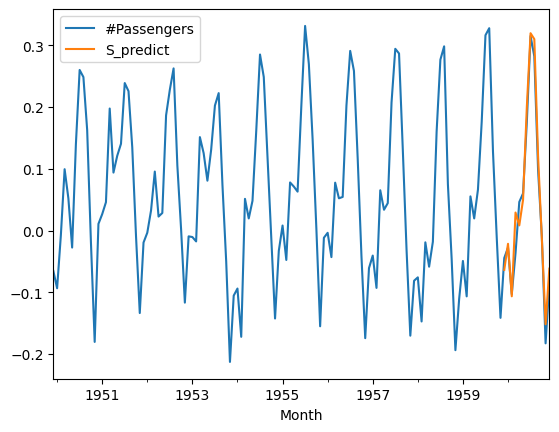

In [ ]:
new_data[['#Passengers','S_predict']].plot()

<Axes: xlabel='Month'>

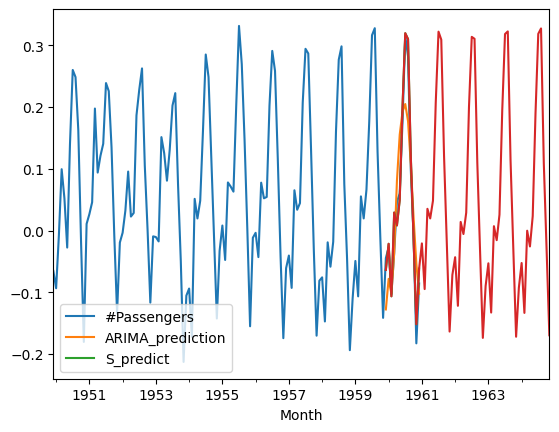

In [ ]:
# Predict for next 5 years ( 12 month * 5 = 60 months)
future=model.forecast(steps=60)
new_data.plot()
future.plot()

In [ ]:
future

,predicted_mean
1959-12-01,-0.063692
1960-01-01,-0.021437
1960-02-01,-0.106490
1960-03-01,0.029197
1960-04-01,0.008326
1960-05-01,0.049696
1960-06-01,0.199274
1960-07-01,0.319703
1960-08-01,0.310132
1960-09-01,0.120260
